# EDA for Selecting Three Continual-Learning Stages

## Objective

Divide the training period **2010–2023** into three chronological stages.

Preferred properties:

- Stage 1 should contain more images than Stage 2.
- Stage 2 should contain more images than Stage 3.
- Stage sizes should not differ excessively.
- Class imbalance should remain reasonably similar.
- Every stage must contain enough FL images.
- A 24-hour gap between consecutive stages must contain only NF images.
- Data from 2024 and 2025–2026 must not influence stage selection.

The requirements are treated as preferences because the solar-cycle distribution may prevent a perfect split.

In [2]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Find the repository root whether the notebook is run from
# the repository root or from data_labeling/eda.
possible_roots = [Path.cwd(), *Path.cwd().parents]

ROOT = next(
    path for path in possible_roots
    if (path / "data_labeling").is_dir()
)

LABEL_DIR = (
    ROOT
    / "data_labeling"
    / "data_labels"
    / "simplified_data_labels"
)

OLD_LABEL_FILE = LABEL_DIR / "labels_2010_2018_binary.csv"
NEW_LABEL_FILE = LABEL_DIR / "labels_2019_2026_july_binary.csv"

print("Repository root:", ROOT)
print("2010–2018 labels:", OLD_LABEL_FILE)
print("2019–2026 labels:", NEW_LABEL_FILE)

assert OLD_LABEL_FILE.is_file()
assert NEW_LABEL_FILE.is_file()

Repository root: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-
2010–2018 labels: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-/data_labeling/data_labels/simplified_data_labels/labels_2010_2018_binary.csv
2019–2026 labels: /Users/piyushluitel/Desktop/PhD/Research/Full-Disk-Attention---Continual-Learning-/data_labeling/data_labels/simplified_data_labels/labels_2019_2026_july_binary.csv


In [3]:
old_labels = pd.read_csv(OLD_LABEL_FILE)
new_labels = pd.read_csv(NEW_LABEL_FILE)

df = pd.concat(
    [old_labels, new_labels],
    ignore_index=True,
)

# Convert both possible label formats into binary targets.
target_mapping = {
    "NF": 0,
    "FL": 1,
    "0": 0,
    "1": 1,
    0: 0,
    1: 1,
}

df["target"] = df["goes_class"].map(target_mapping)

# Extract the observation time from filenames such as:
# 2019/01/01/HMI.m2019.01.01_00.00.00.jpg
timestamp_parts = df["label"].str.extract(
    r"HMI\.m(?P<date>\d{4}\.\d{2}\.\d{2})_"
    r"(?P<time>\d{2}\.\d{2}\.\d{2})"
)

df["timestamp"] = pd.to_datetime(
    timestamp_parts["date"] + " " + timestamp_parts["time"],
    format="%Y.%m.%d %H.%M.%S",
    errors="coerce",
)

df["year"] = df["timestamp"].dt.year

# Only 2010–2023 are used to determine the training stages.
stage_data = (
    df[df["year"].between(2010, 2023)]
    .dropna(subset=["timestamp", "target"])
    .copy()
)

stage_data["target"] = stage_data["target"].astype(int)

print("Training-period images:", len(stage_data))
print("First timestamp:", stage_data["timestamp"].min())
print("Last timestamp:", stage_data["timestamp"].max())
print("Missing timestamps:", stage_data["timestamp"].isna().sum())
print("Missing targets:", stage_data["target"].isna().sum())
print("Duplicate image paths:", stage_data["label"].duplicated().sum())

Training-period images: 106093
First timestamp: 2010-12-06 07:00:00
Last timestamp: 2023-12-31 23:00:00
Missing timestamps: 0
Missing targets: 0
Duplicate image paths: 0


In [4]:
yearly = (
    stage_data
    .groupby("year")["target"]
    .agg(total="size", FL="sum")
    .reset_index()
)

yearly["NF"] = yearly["total"] - yearly["FL"]
yearly["FL_percent"] = 100 * yearly["FL"] / yearly["total"]

yearly["NF_to_FL"] = np.where(
    yearly["FL"] > 0,
    yearly["NF"] / yearly["FL"],
    np.inf,
)

display(
    yearly.round({
        "FL_percent": 2,
        "NF_to_FL": 2,
    })
)

,year,total,FL,NF,FL_percent,NF_to_FL
0,2010,562,0,562,0.00,inf
1,2011,6528,1235,5293,18.92,4.29
2,2012,6516,1358,5158,20.84,3.80
3,2013,7656,1436,6220,18.76,4.33
4,2014,8405,2702,5703,32.15,2.11
5,2015,8511,1664,6847,19.55,4.11
6,2016,8337,250,8087,3.00,32.35
7,2017,8377,330,8047,3.94,24.38
8,2018,8393,0,8393,0.00,inf
9,2019,8421,24,8397,0.29,349.88


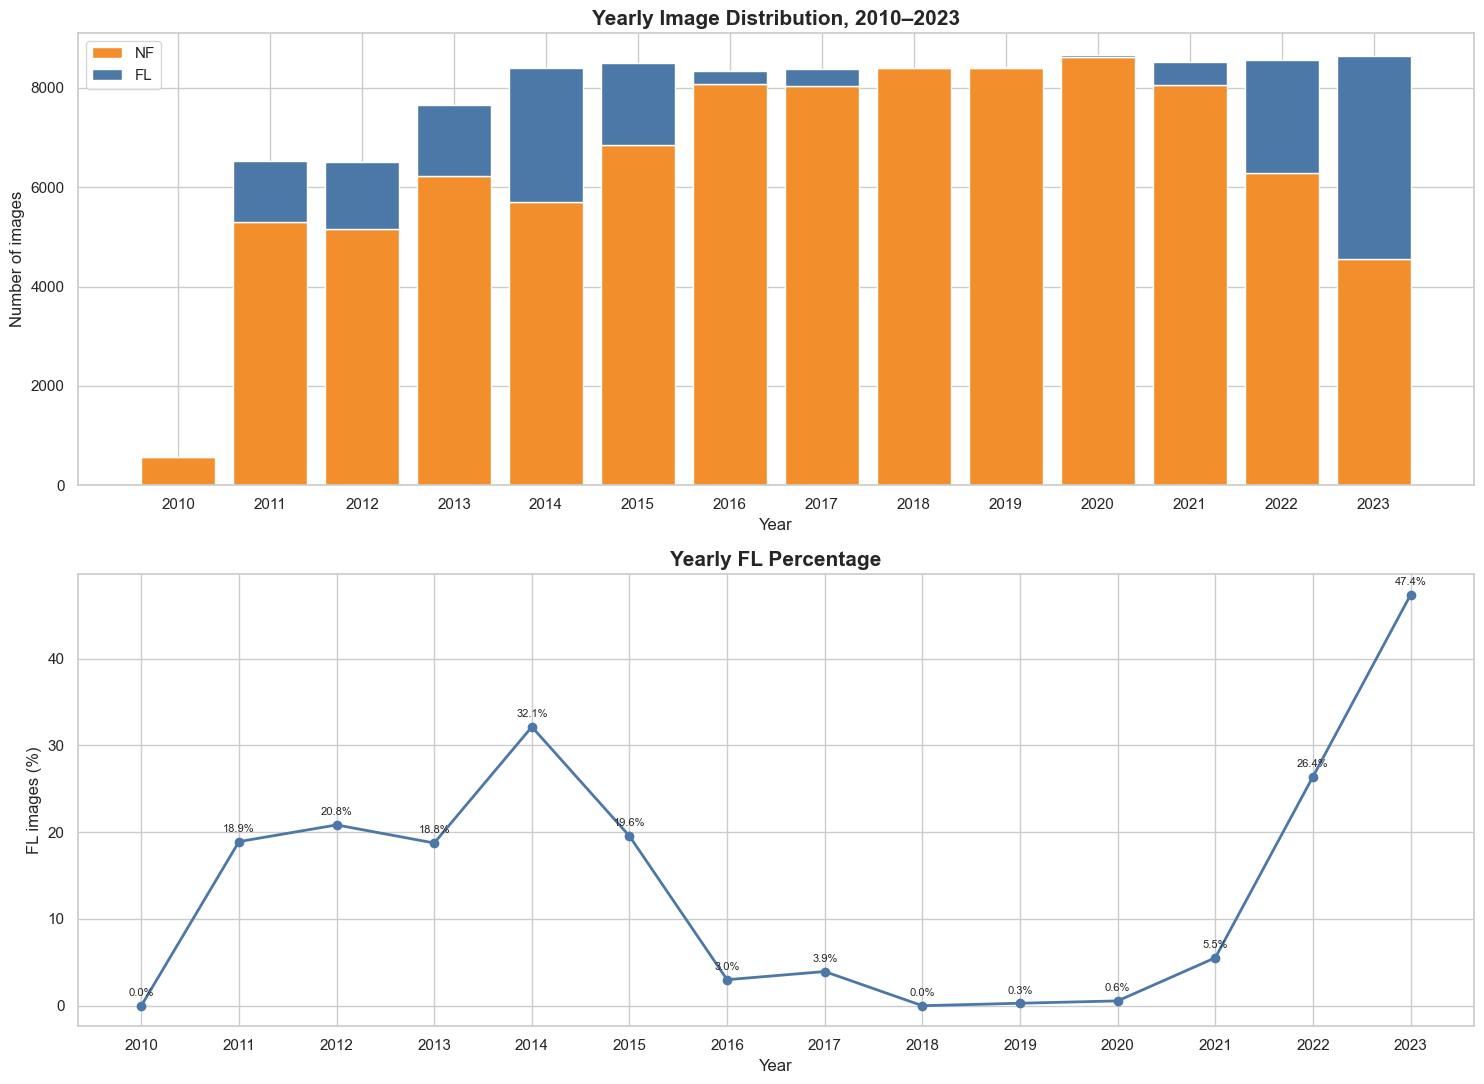

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11))

# Number of NF and FL images.
axes[0].bar(
    yearly["year"],
    yearly["NF"],
    label="NF",
    color="#F28E2B",
)

axes[0].bar(
    yearly["year"],
    yearly["FL"],
    bottom=yearly["NF"],
    label="FL",
    color="#4C78A8",
)

axes[0].set_title(
    "Yearly Image Distribution, 2010–2023",
    fontsize=15,
    fontweight="bold",
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of images")
axes[0].set_xticks(yearly["year"])
axes[0].legend()

# FL percentage.
axes[1].plot(
    yearly["year"],
    yearly["FL_percent"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
)

for _, row in yearly.iterrows():
    axes[1].annotate(
        f"{row['FL_percent']:.1f}%",
        (row["year"], row["FL_percent"]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )

axes[1].set_title(
    "Yearly FL Percentage",
    fontsize=15,
    fontweight="bold",
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("FL images (%)")
axes[1].set_xticks(yearly["year"])

plt.tight_layout()
plt.show()

In [6]:
def summarize_stage(data, stage_name, start_year, end_year):
    """Calculate the distribution inside one stage."""

    selected = data[
        data["year"].between(start_year, end_year)
    ]

    total = len(selected)
    fl_count = int(selected["target"].sum())
    nf_count = total - fl_count

    fl_percent = (
        100 * fl_count / total
        if total > 0
        else np.nan
    )

    nf_to_fl = (
        nf_count / fl_count
        if fl_count > 0
        else np.inf
    )

    return {
        "period": stage_name,
        "years": f"{start_year}-{end_year}",
        "start_year": start_year,
        "end_year": end_year,
        "total": total,
        "FL": fl_count,
        "NF": nf_count,
        "FL_percent": fl_percent,
        "NF_to_FL": nf_to_fl,
    }


def evaluate_split(data, cut_1, cut_2):
    """
    Create three stages:

    Stage 1: 2010 through cut_1
    Stage 2: cut_1 + 1 through cut_2
    Stage 3: cut_2 + 1 through 2023
    """

    details = [
        summarize_stage(data, "Stage 1", 2010, cut_1),
        summarize_stage(data, "Stage 2", cut_1 + 1, cut_2),
        summarize_stage(data, "Stage 3", cut_2 + 1, 2023),
    ]

    totals = np.array(
        [stage["total"] for stage in details],
        dtype=float,
    )

    fl_counts = np.array(
        [stage["FL"] for stage in details],
        dtype=float,
    )

    nf_counts = np.array(
        [stage["NF"] for stage in details],
        dtype=float,
    )

    # Lower size variation means more similar stage sizes.
    size_variation = totals.std(ddof=0) / totals.mean()

    # Smoothed NF:FL ratios avoid division by zero.
    smoothed_ratios = (
        (nf_counts + 0.5)
        / (fl_counts + 0.5)
    )

    # Log scale prevents extremely large ratios from
    # dominating the calculation.
    imbalance_variation = np.log(
        smoothed_ratios
    ).std(ddof=0)

    strictly_decreasing = (
        totals[0] > totals[1] > totals[2]
    )

    adjacent_size_ratios = np.array([
        totals[1] / totals[0],
        totals[2] / totals[1],
    ])

    return {
        "stage_1": details[0]["years"],
        "stage_2": details[1]["years"],
        "stage_3": details[2]["years"],
        "cut_1": cut_1,
        "cut_2": cut_2,
        "stage_1_total": int(totals[0]),
        "stage_2_total": int(totals[1]),
        "stage_3_total": int(totals[2]),
        "stage_1_FL": int(fl_counts[0]),
        "stage_2_FL": int(fl_counts[1]),
        "stage_3_FL": int(fl_counts[2]),
        "stage_1_FL_percent": details[0]["FL_percent"],
        "stage_2_FL_percent": details[1]["FL_percent"],
        "stage_3_FL_percent": details[2]["FL_percent"],
        "stage_1_NF_to_FL": details[0]["NF_to_FL"],
        "stage_2_NF_to_FL": details[1]["NF_to_FL"],
        "stage_3_NF_to_FL": details[2]["NF_to_FL"],
        "size_variation": size_variation,
        "imbalance_variation": imbalance_variation,
        "strictly_decreasing": strictly_decreasing,
        "minimum_FL": int(fl_counts.min()),
        "minimum_adjacent_size_ratio": adjacent_size_ratios.min(),
        "details": details,
    }

In [7]:
candidate_rows = []

# Two cut years are selected from 2010–2022.
# Each resulting stage must contain at least one year.
for cut_1, cut_2 in combinations(range(2010, 2023), 2):
    candidate_rows.append(
        evaluate_split(stage_data, cut_1, cut_2)
    )

candidates = pd.DataFrame(candidate_rows)

print("Total chronological candidates:", len(candidates))
print(
    "Candidates with decreasing sizes:",
    candidates["strictly_decreasing"].sum(),
)

Total chronological candidates: 78
Candidates with decreasing sizes: 8


In [8]:
MIN_FL_PER_STAGE = 1000

eligible = candidates[
    candidates["strictly_decreasing"]
    & (candidates["minimum_FL"] >= MIN_FL_PER_STAGE)
].copy()

print("Minimum FL images required:", MIN_FL_PER_STAGE)
print("Eligible candidates:", len(eligible))

display(
    eligible[
        [
            "stage_1",
            "stage_2",
            "stage_3",
            "stage_1_total",
            "stage_2_total",
            "stage_3_total",
            "stage_1_FL",
            "stage_2_FL",
            "stage_3_FL",
            "size_variation",
            "imbalance_variation",
        ]
    ]
    .sort_values(
        ["size_variation", "imbalance_variation"]
    )
    .head(15)
    .round(3)
)

Minimum FL images required: 1000
Eligible candidates: 4


,stage_1,stage_2,stage_3,stage_1_total,stage_2_total,stage_3_total,stage_1_FL,stage_2_FL,stage_3_FL,size_variation,imbalance_variation
67,2010-2017,2018-2022,2023-2023,54892,42557,8644,8975,2801,4094,0.553,1.047
71,2010-2018,2019-2022,2023-2023,63285,34164,8644,8975,2801,4094,0.631,0.977
74,2010-2019,2020-2022,2023-2023,71706,25743,8644,8999,2777,4094,0.753,0.908
76,2010-2020,2021-2022,2023-2023,80373,17076,8644,9047,2729,4094,0.905,0.844


In [9]:
MAX_SHIFT_DAYS = 30
GAP_HOURS = 24

# If duplicate timestamps exist, mark the hour as FL if any
# corresponding row has an FL label.
hourly_target = (
    stage_data
    .groupby("timestamp")["target"]
    .max()
    .sort_index()
)

# Reindex to an exact hourly timeline.
complete_hours = pd.date_range(
    hourly_target.index.min().floor("h"),
    hourly_target.index.max().ceil("h"),
    freq="h",
)

hourly_target = hourly_target.reindex(complete_hours)


def find_nearest_nf_gap(boundary, maximum_shift_days=30):
    """
    Find the nearest complete 24-hour NF-only window
    around a nominal stage boundary.
    """

    boundary = pd.Timestamp(boundary)

    rolling_count = hourly_target.rolling(
        GAP_HOURS,
        min_periods=GAP_HOURS,
    ).count()

    rolling_fl = hourly_target.rolling(
        GAP_HOURS,
        min_periods=GAP_HOURS,
    ).sum()

    valid_ends = hourly_target.index[
        (rolling_count == GAP_HOURS)
        & (rolling_fl == 0)
    ]

    if len(valid_ends) == 0:
        return None

    possible_gaps = pd.DataFrame({
        "gap_end": valid_ends,
    })

    possible_gaps["gap_start"] = (
        possible_gaps["gap_end"]
        - pd.Timedelta(hours=GAP_HOURS - 1)
    )

    # The next sample after the gap is the effective cut.
    possible_gaps["actual_cut"] = (
        possible_gaps["gap_end"]
        + pd.Timedelta(hours=1)
    )

    possible_gaps["shift_hours"] = (
        possible_gaps["actual_cut"] - boundary
    ).dt.total_seconds() / 3600

    possible_gaps["absolute_shift_hours"] = (
        possible_gaps["shift_hours"].abs()
    )

    possible_gaps = possible_gaps[
        possible_gaps["absolute_shift_hours"]
        <= maximum_shift_days * 24
    ]

    if possible_gaps.empty:
        return None

    return (
        possible_gaps
        .sort_values("absolute_shift_hours")
        .iloc[0]
        .to_dict()
    )

In [10]:
gap_rows = []

for boundary_year in range(2011, 2024):
    nominal_boundary = pd.Timestamp(
        year=boundary_year,
        month=1,
        day=1,
    )

    result = find_nearest_nf_gap(
        nominal_boundary,
        maximum_shift_days=MAX_SHIFT_DAYS,
    )

    if result is None:
        gap_rows.append({
            "boundary_year": boundary_year,
            "nominal_boundary": nominal_boundary,
            "gap_found": False,
            "gap_start": pd.NaT,
            "gap_end": pd.NaT,
            "actual_cut": pd.NaT,
            "shift_days": np.nan,
        })
    else:
        gap_rows.append({
            "boundary_year": boundary_year,
            "nominal_boundary": nominal_boundary,
            "gap_found": True,
            "gap_start": result["gap_start"],
            "gap_end": result["gap_end"],
            "actual_cut": result["actual_cut"],
            "shift_days": (
                result["absolute_shift_hours"] / 24
            ),
        })

gap_table = pd.DataFrame(gap_rows)

display(gap_table.round({"shift_days": 2}))

,boundary_year,nominal_boundary,gap_found,gap_start,gap_end,actual_cut,shift_days
0,2011,2011-01-01,True,2010-12-31 00:00:00,2010-12-31 23:00:00,2011-01-01 00:00:00,0.00
1,2012,2012-01-01,True,2011-12-31 17:00:00,2012-01-01 16:00:00,2012-01-01 17:00:00,0.71
2,2013,2013-01-01,True,2012-12-31 00:00:00,2012-12-31 23:00:00,2013-01-01 00:00:00,0.00
3,2014,2014-01-01,True,2013-12-29 22:00:00,2013-12-30 21:00:00,2013-12-30 22:00:00,1.08
4,2015,2015-01-01,True,2014-12-31 00:00:00,2014-12-31 23:00:00,2015-01-01 00:00:00,0.00
5,2016,2016-01-01,True,2015-12-31 00:00:00,2015-12-31 23:00:00,2016-01-01 00:00:00,0.00
6,2017,2017-01-01,True,2016-12-30 10:00:00,2016-12-31 09:00:00,2016-12-31 10:00:00,0.58
7,2018,2018-01-01,True,2017-12-31 00:00:00,2017-12-31 23:00:00,2018-01-01 00:00:00,0.00
8,2019,2019-01-01,True,2018-12-30 00:00:00,2018-12-30 23:00:00,2018-12-31 00:00:00,1.00
9,2020,2020-01-01,True,2019-12-31 00:00:00,2019-12-31 23:00:00,2020-01-01 00:00:00,0.00


In [11]:
gap_lookup = gap_table.set_index(
    "boundary_year"
).to_dict("index")


def add_gap_information(row):
    # If Stage 1 ends in 2019, the boundary year is 2020.
    boundary_1_year = int(row["cut_1"]) + 1
    boundary_2_year = int(row["cut_2"]) + 1

    gap_1 = gap_lookup[boundary_1_year]
    gap_2 = gap_lookup[boundary_2_year]

    both_gaps_found = (
        gap_1["gap_found"]
        and gap_2["gap_found"]
    )

    maximum_shift = (
        max(
            gap_1["shift_days"],
            gap_2["shift_days"],
        )
        if both_gaps_found
        else np.inf
    )

    return pd.Series({
        "gap_1_start": gap_1["gap_start"],
        "gap_1_end": gap_1["gap_end"],
        "gap_1_shift_days": gap_1["shift_days"],
        "gap_2_start": gap_2["gap_start"],
        "gap_2_end": gap_2["gap_end"],
        "gap_2_shift_days": gap_2["shift_days"],
        "both_nf_gaps_found": both_gaps_found,
        "maximum_gap_shift_days": maximum_shift,
    })


gap_information = eligible.apply(
    add_gap_information,
    axis=1,
)

eligible = pd.concat(
    [
        eligible.reset_index(drop=True),
        gap_information.reset_index(drop=True),
    ],
    axis=1,
)

eligible = eligible[
    eligible["both_nf_gaps_found"]
].copy()

print(
    "Candidates satisfying the NF-only gap requirement:",
    len(eligible),
)

Candidates satisfying the NF-only gap requirement: 4


In [12]:
SIZE_WEIGHT = 0.45
IMBALANCE_WEIGHT = 0.45
GAP_WEIGHT = 0.10


def min_max_scale(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            np.zeros(len(series)),
            index=series.index,
        )

    return (series - minimum) / (maximum - minimum)


eligible["size_score"] = min_max_scale(
    eligible["size_variation"]
)

eligible["imbalance_score"] = min_max_scale(
    eligible["imbalance_variation"]
)

eligible["gap_score"] = min_max_scale(
    eligible["maximum_gap_shift_days"]
)

eligible["combined_score"] = (
    SIZE_WEIGHT * eligible["size_score"]
    + IMBALANCE_WEIGHT * eligible["imbalance_score"]
    + GAP_WEIGHT * eligible["gap_score"]
)

ranked_candidates = eligible.sort_values(
    "combined_score"
).reset_index(drop=True)

columns_to_show = [
    "stage_1",
    "stage_2",
    "stage_3",
    "stage_1_total",
    "stage_2_total",
    "stage_3_total",
    "stage_1_FL",
    "stage_2_FL",
    "stage_3_FL",
    "stage_1_NF_to_FL",
    "stage_2_NF_to_FL",
    "stage_3_NF_to_FL",
    "size_variation",
    "imbalance_variation",
    "maximum_gap_shift_days",
    "combined_score",
]

display(
    ranked_candidates[columns_to_show]
    .head(15)
    .round(3)
)

,stage_1,stage_2,stage_3,stage_1_total,stage_2_total,stage_3_total,stage_1_FL,stage_2_FL,stage_3_FL,stage_1_NF_to_FL,stage_2_NF_to_FL,stage_3_NF_to_FL,size_variation,imbalance_variation,maximum_gap_shift_days,combined_score
0,2010-2019,2020-2022,2023-2023,71706,25743,8644,8999,2777,4094,6.968,8.270,1.111,0.753,0.908,0.0,0.398
1,2010-2017,2018-2022,2023-2023,54892,42557,8644,8975,2801,4094,5.116,14.194,1.111,0.553,1.047,0.0,0.450
2,2010-2020,2021-2022,2023-2023,80373,17076,8644,9047,2729,4094,7.884,5.257,1.111,0.905,0.844,0.0,0.450
3,2010-2018,2019-2022,2023-2023,63285,34164,8644,8975,2801,4094,6.051,11.197,1.111,0.631,0.977,1.0,0.494


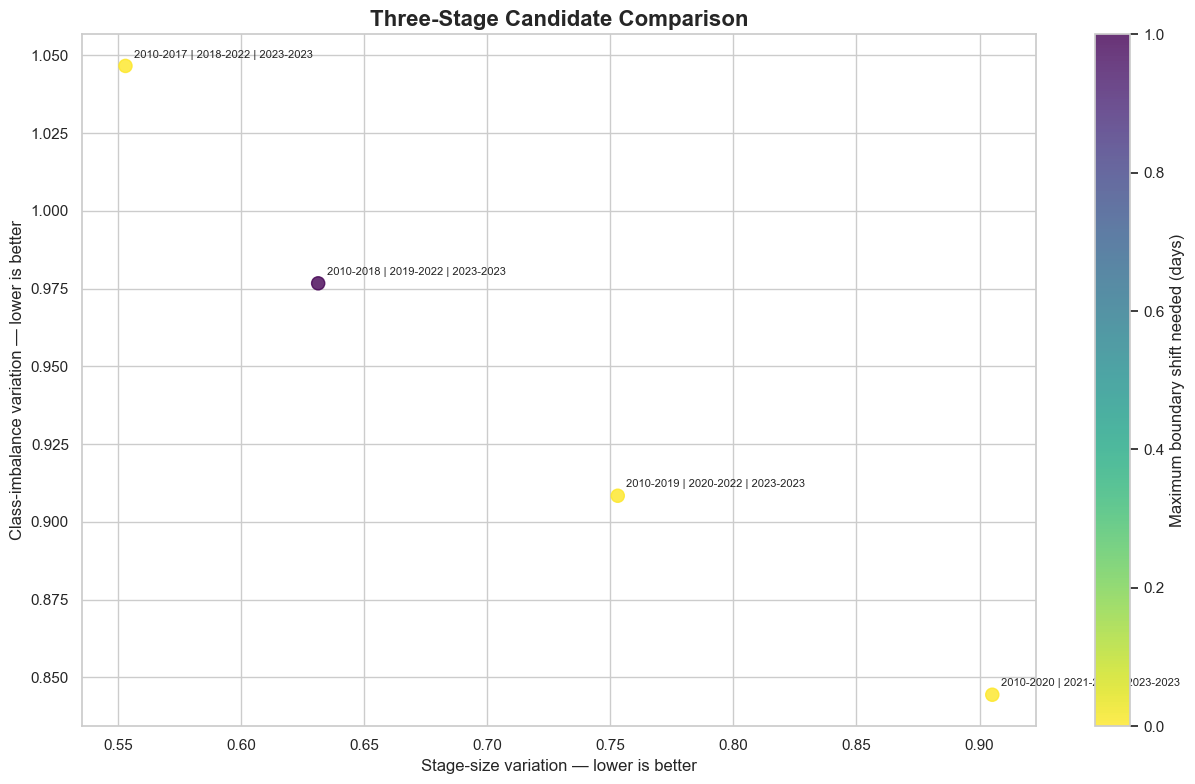

In [13]:
plt.figure(figsize=(13, 8))

scatter = plt.scatter(
    eligible["size_variation"],
    eligible["imbalance_variation"],
    c=eligible["maximum_gap_shift_days"],
    cmap="viridis_r",
    s=90,
    alpha=0.8,
)

plt.colorbar(
    scatter,
    label="Maximum boundary shift needed (days)",
)

top_candidates = ranked_candidates.head(8)

for _, row in top_candidates.iterrows():
    label = (
        f"{row['stage_1']} | "
        f"{row['stage_2']} | "
        f"{row['stage_3']}"
    )

    plt.annotate(
        label,
        (
            row["size_variation"],
            row["imbalance_variation"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
    )

plt.title(
    "Three-Stage Candidate Comparison",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Stage-size variation — lower is better")
plt.ylabel("Class-imbalance variation — lower is better")

plt.tight_layout()
plt.show()

In [14]:
candidate_number = 0

chosen = ranked_candidates.iloc[candidate_number]

chosen_details = pd.DataFrame(chosen["details"])

print("Selected candidate number:", candidate_number)
print(
    "Nominal split:",
    chosen["stage_1"],
    "|",
    chosen["stage_2"],
    "|",
    chosen["stage_3"],
)

print("\nNF-only gap between Stages 1 and 2:")
print(chosen["gap_1_start"], "through", chosen["gap_1_end"])

print("\nNF-only gap between Stages 2 and 3:")
print(chosen["gap_2_start"], "through", chosen["gap_2_end"])

print("\nCombined score:", round(chosen["combined_score"], 3))

display(
    chosen_details[
        [
            "period",
            "years",
            "total",
            "FL",
            "NF",
            "FL_percent",
            "NF_to_FL",
        ]
    ].round({
        "FL_percent": 2,
        "NF_to_FL": 2,
    })
)

Selected candidate number: 0
Nominal split: 2010-2019 | 2020-2022 | 2023-2023

NF-only gap between Stages 1 and 2:
2019-12-31 00:00:00 through 2019-12-31 23:00:00

NF-only gap between Stages 2 and 3:
2022-12-31 00:00:00 through 2022-12-31 23:00:00

Combined score: 0.398


,period,years,total,FL,NF,FL_percent,NF_to_FL
0,Stage 1,2010-2019,71706,8999,62707,12.55,6.97
1,Stage 2,2020-2022,25743,2777,22966,10.79,8.27
2,Stage 3,2023-2023,8644,4094,4550,47.36,1.11


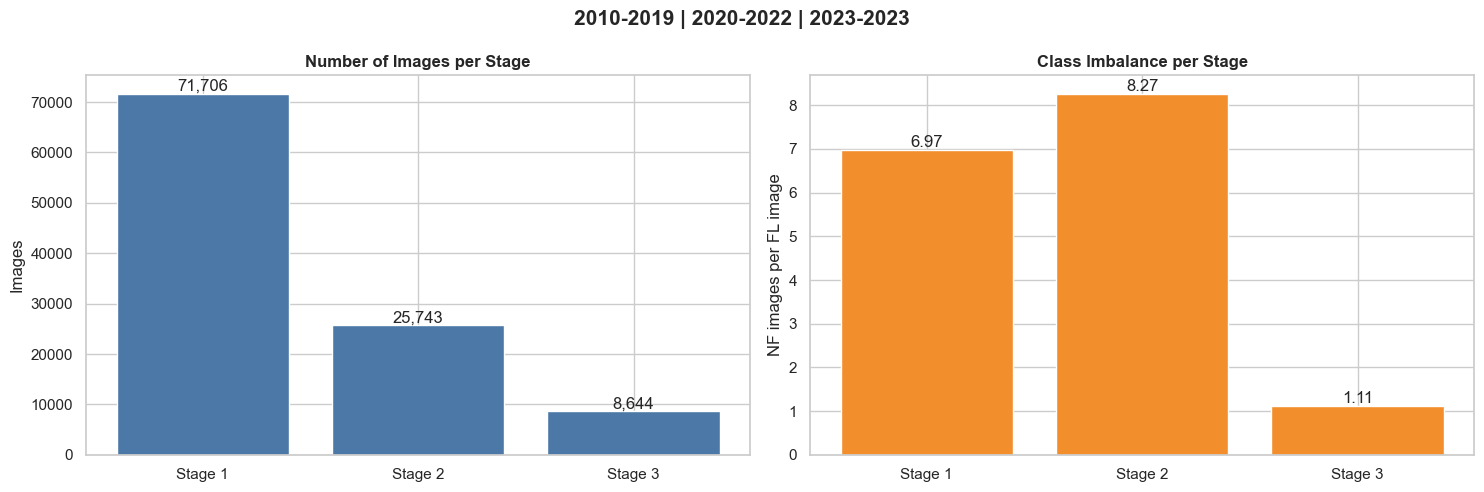

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stage_names = chosen_details["period"]

axes[0].bar(
    stage_names,
    chosen_details["total"],
    color="#4C78A8",
)

for index, value in enumerate(chosen_details["total"]):
    axes[0].text(
        index,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
    )

axes[0].set_title(
    "Number of Images per Stage",
    fontweight="bold",
)
axes[0].set_ylabel("Images")

axes[1].bar(
    stage_names,
    chosen_details["NF_to_FL"],
    color="#F28E2B",
)

for index, value in enumerate(chosen_details["NF_to_FL"]):
    axes[1].text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

axes[1].set_title(
    "Class Imbalance per Stage",
    fontweight="bold",
)
axes[1].set_ylabel("NF images per FL image")

fig.suptitle(
    (
        f"{chosen['stage_1']} | "
        f"{chosen['stage_2']} | "
        f"{chosen['stage_3']}"
    ),
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()